In [ ]:
# Dataset statistics and Checking

import os

def count(path):
    total = 0

    if not os.path.exists(path):
        print("Path not found:", path)
        return 0

    classes = sorted([c for c in os.listdir(path) if os.path.isdir(os.path.join(path, c))])

    for c in classes:
        folder = os.path.join(path, c)

        num_images = len(os.listdir(folder))
        print(f"{c}: {num_images}")

        total += num_images

    print(f"classes: {len(classes)}")
    print("=" * 30 )
    return total


train = count("C:/Cpyprojects/train")
test = count("C:/Cpyprojects/test")


print(f"Train Total: {train}")
print(f"Test Total: {test}")
print(f"Total: {train + test}")

In [ ]:

# Data Resizing and Dimension Reduction

import os
import cv2


train = "C:/Cpyprojects/train"
test = "C:/Cpyprojects/test"

SIZE = (64, 64)

def resize(path):
    if not os.path.exists(path):
        return


    total_resized = 0

    for c in os.listdir(path):
        folder = os.path.join(path, c)

        if not os.path.isdir(folder):
            continue

        print("class:", c)

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)

            try:
                img = cv2.imread(img_path)

                if img is None:
                    continue

                resized = cv2.resize(img, SIZE)

                cv2.imwrite(img_path, resized)

                total_resized += 1

            except Exception as e:
                continue

    print(f"Done: {path}")
    print(f"resized: {total_resized}")


resize(train)
resize(test)



In [ ]:
# Data Cleaning and Corrupted Image Removal


import os
import cv2


train = "C:/Cpyprojects/train"
test = "C:/Cpyprojects/test"

def cleaning(path):
    if not os.path.exists(path):
        print("Path not found:", path)
        return
    bad = 0

    for c in os.listdir(path):
        folder = os.path.join(path, c)

        if not os.path.isdir(folder):
            continue

        print("class:", c)

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)

            try:
                img = cv2.imread(img_path)

                if img is None:
                    print("Removed:", img_path)
                    os.remove(img_path)
                    bad += 1

            except Exception as e:
                os.remove(img_path)
                bad += 1

    print("-" * 30)
    print("Total removed:", bad)


cleaning(train)
cleaning(test)


In [ ]:
# Feature Extraction using HOG and LBP

import os
import cv2
import numpy as np
from skimage.feature import hog, local_binary_pattern

print("Started")

train = "C:/Cpyprojects/train"
test = "C:/Cpyprojects/test"

radius = 1
n_points = 8 * radius

classes = sorted(os.listdir(train))
print("Classes:", classes)

# حفظ mapping
mapping = {c: i for i, c in enumerate(classes)}
np.save("class_map.npy", mapping)



def feature(path):
    X = []
    y = []

    for label, c in enumerate(classes):

        folder = os.path.join(path, c)

        if not os.path.isdir(folder):
            continue

        print(f"\nProcessing: {c}")

        imgs = os.listdir(folder)

        for i, img_name in enumerate(imgs):

            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            try:
                hog_features = hog(
                    img,
                    orientations=9,          
                    pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2),   
                    visualize=False
                )

                lbp = local_binary_pattern(img, n_points, radius, method="uniform")

                hist, _ = np.histogram(
                    lbp.ravel(),
                    bins=np.arange(0, n_points + 3),
                    range=(0, n_points + 2)
                )

                hist = hist.astype("float")
                hist /= (hist.sum() + 1e-6)

                features = np.hstack([hog_features, hist])

                X.append(features)
                y.append(label)

            except:
                continue

    return np.array(X), np.array(y)


X_train, y_train = feature(train)

X_test, y_test = feature(test)

np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

print("Train:", len(X_train))
print("Test:", len(X_test))
print("Feature size:", len(X_train[0]))

In [ ]:
# Model Training and Evaluation

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import chi2, SelectKBest 
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")
class_map = np.load("class_map.npy", allow_pickle=True).item()

class_names = list(class_map.keys())
print(f"classes: {class_names}")


X_train_sample = X_train
y_train_sample = y_train
X_test_sample = X_test
y_test_sample = y_test


scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_sample)
X_test_scaled = scaler.transform(X_test_sample)

selector = SelectKBest(score_func=chi2, k=300) 
X_train_selected = selector.fit_transform(X_train_scaled, y_train_sample)
X_test_selected = selector.transform(X_test_scaled)

print(f"reduced from {X_train_sample.shape[1]} to {X_train_selected.shape[1]}")


print("\nTraining SVM")

svm_model = SVC(kernel='rbf', C=10, gamma='scale', verbose=True)
svm_model.fit(X_train_selected, y_train_sample)

print("SVM Training Complete!")

print("\nTraining Random Forest")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_selected, y_train_sample)
print("Random Forest Training Complete!")

print("\nEvaluating")

svm_preds = svm_model.predict(X_test_selected)
svm_acc = accuracy_score(y_test_sample, svm_preds)
rf_preds = rf_model.predict(X_test_selected)    
rf_acc = accuracy_score(y_test_sample, rf_preds)

print("\n" + "=" * 40)
print("=" * 40)
print(f"SVM Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)")
print(f"Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print("=" * 40)
import pickle 


with open("svm_trained.pkl", "wb") as f:
    pickle.dump(svm_model, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("selector.pkl", "wb") as f:
    pickle.dump(selector, f)
with open("class_map.pkl", "wb") as f:
    pickle.dump(class_map, f)
with open("rf_trained.pkl", "wb") as f:
    pickle.dump(rf_model, f)



In [ ]:
# input Prediction

import cv2
import numpy as np
import pickle
from skimage.feature import hog, local_binary_pattern


with open("svm_trained.pkl", "rb") as f:
    svm_model = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open("selector.pkl", "rb") as f:
    selector = pickle.load(f)
with open("class_map.pkl", "rb") as f:
    class_map = pickle.load(f)
with open("rf_trained.pkl", "rb") as f:
    rf_model = pickle.load(f)

inv_class_map = {v: k for k, v in class_map.items()}



def get_features(img):
    img = cv2.resize(img, (64, 64))
    
    hog_feat = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False)
    
    radius = 1
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    
    return np.hstack([hog_feat, hist])



def predict_emotion(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return "Error"
    
    features = get_features(img)
    
    features = features.reshape(1, -1)
    
    features_scaled = scaler.transform(features)
    features_selected = selector.transform(features_scaled)
    
    pred_num = svm_model.predict(features_selected)[0]
    emotion = inv_class_map[pred_num]
    pred_num_rf = rf_model.predict(features_selected)[0]
    emotion= inv_class_map[pred_num]
    return emotion



image_to_test = "C:\\Cpyprojects\\test\\neutral\\PrivateTest_2409840.jpg"

print(f"Testing image: {image_to_test}")
result = predict_emotion(image_to_test)
result2 = predict_emotion(image_to_test)


print("\n" + "="*30)
print(f" SVM Predicted Emotion: {result.upper()}")
print(f" Random Forest Predicted Emotion: {result2.upper()}")
print("="*30)

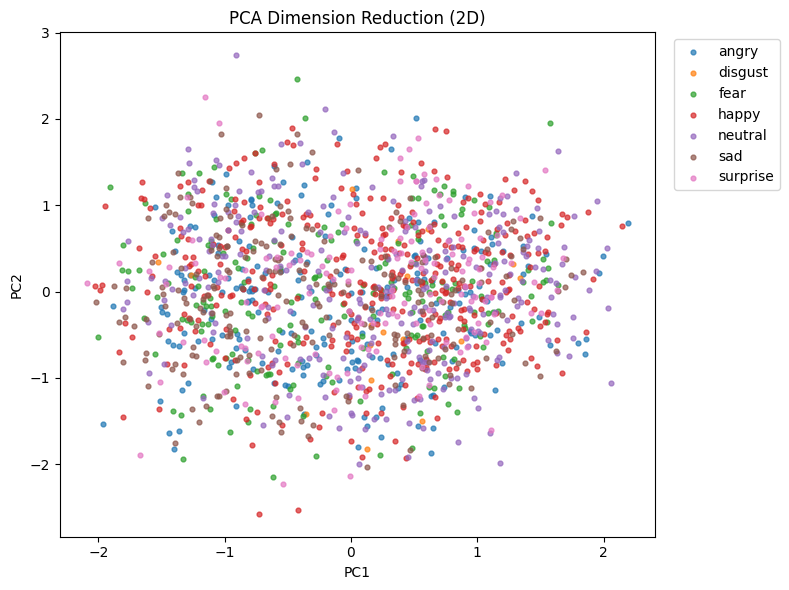

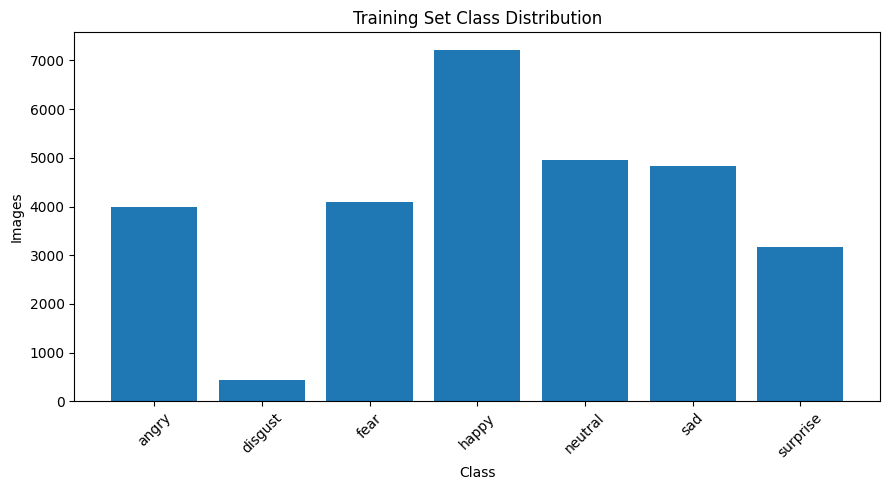

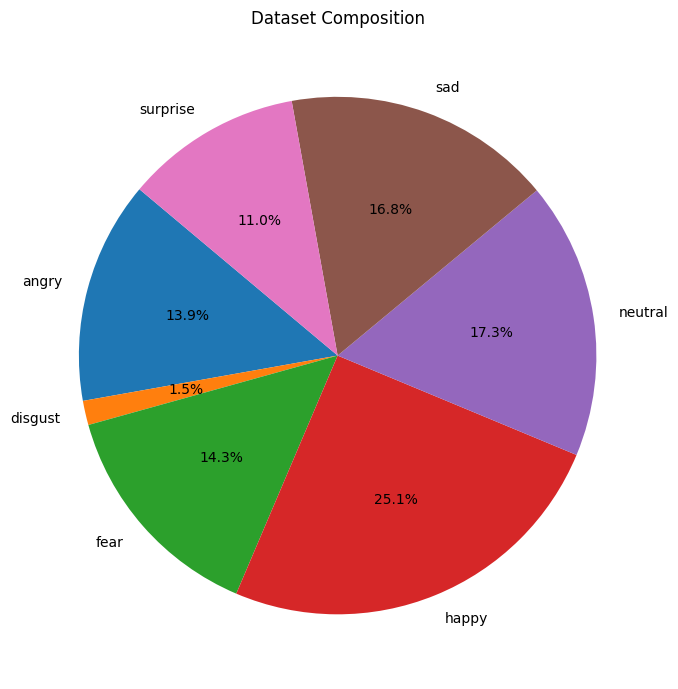

In [20]:
# Data Visualization and Analysis


import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter


X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

try:
    class_map = np.load("class_map.npy", allow_pickle=True).item()
    inv = {v:k for k,v in class_map.items()}
    labels = [inv[i] for i in sorted(inv)]
except:
    labels = [str(i) for i in sorted(np.unique(y_train))]

idx = np.random.choice(len(X_train), size=min(1500, len(X_train)), replace=False)
X_sample = X_train[idx]
y_sample = y_train[idx]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8,6))
for c in np.unique(y_sample):
    m = y_sample == c
    plt.scatter(X_pca[m,0], X_pca[m,1], s=12, alpha=0.7, label=labels[int(c)])
plt.title("PCA Dimension Reduction (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


counts = Counter(y_train)
vals = [counts[i] for i in sorted(counts)]
names = [labels[int(i)] for i in sorted(counts)]

plt.figure(figsize=(9,5))
plt.bar(names, vals)
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,7))
plt.pie(vals, labels=names, autopct="%1.1f%%", startangle=140)
plt.title("Dataset Composition")
plt.tight_layout()
plt.show()
